### Библиотеки

In [1]:
from transformers import pipeline
from glob import glob
import os
from tqdm import tqdm

2025-11-26 22:17:14.338808: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764184634.361983  257773 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764184634.369048  257773 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1764184634.387071  257773 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764184634.387094  257773 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1764184634.387096  257773 computation_placer.cc:177] computation placer alr

### Сгенерированные дпнные

In [2]:
experiments = [
    "base_dynamic",
    "base_dynamic_one_shot",
    "mult_1_dynamic",
    "mult_1_dynamic_one_shot",
    "mult_1_right_dynamic",
    "mult_1_right_dynamic_one_shot"
]

steps = [x * 100 for x in range(1, 11)]

### Пайплайн

In [3]:
pipe = pipeline(
    "image-segmentation", 
    model="briaai/RMBG-1.4", 
    trust_remote_code=True,
    device='cuda'
)

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Device set to use cuda


### Обработка данных

In [11]:
# исходных
real_files = glob("dataset/few_shot/instance_images/*", recursive=True)
os.makedirs("dataset/few_shot/instance_images_clean", exist_ok=True)
for path in tqdm(real_files):
    name = path.split("/")[-1].strip(".jpg")
    image = pipe(path)
    image.save(f"dataset/few_shot/instance_images_clean/{name}.png")

100%|██████████| 5/5 [00:03<00:00,  1.38it/s]


In [7]:
# сгенерированных
count = 0
for exp in experiments:
    print(f"Processing: {exp}")
    for step in tqdm(steps):
        os.makedirs(f"{exp}/checkpoint-{step}/sample/clean_sample", exist_ok=True)
        path = f"{exp}/checkpoint-{step}/sample/base_*.png"
        image_path_all = glob(path)
        
        for path in image_path_all:
            image = pipe(path)
            
            name = path.split("/")[-1]
            image.save(f"{exp}/checkpoint-{step}/sample/clean_sample/{name}")

Processing: base_dynamic


100%|██████████| 10/10 [02:09<00:00, 12.99s/it]


Processing: base_dynamic_one_shot


100%|██████████| 10/10 [02:15<00:00, 13.54s/it]


Processing: mult_1_dynamic


...

100%|██████████| 10/10 [02:14<00:00, 13.42s/it]


Processing: mult_1_right_dynamic


100%|██████████| 10/10 [02:06<00:00, 12.66s/it]


Processing: mult_1_right_dynamic_one_shot


100%|██████████| 10/10 [02:18<00:00, 13.85s/it]


### Тонкости применения Clip при очищение заднего плана

In [1]:
import torch
import clip
from PIL import Image
from typing import Union
from torchvision.transforms import ToPILImage

device = "cuda" if torch.cuda.is_available() else "cpu"
model, preprocess = clip.load("ViT-B/32", device=device)

In [2]:
path_1 = "base_dynamic/checkpoint-400/sample/base_0.png"
path_2 = "base_dynamic/checkpoint-400/sample/clean_sample/base_0.png"

base_dynamic/checkpoint-400/sample/base_0.png


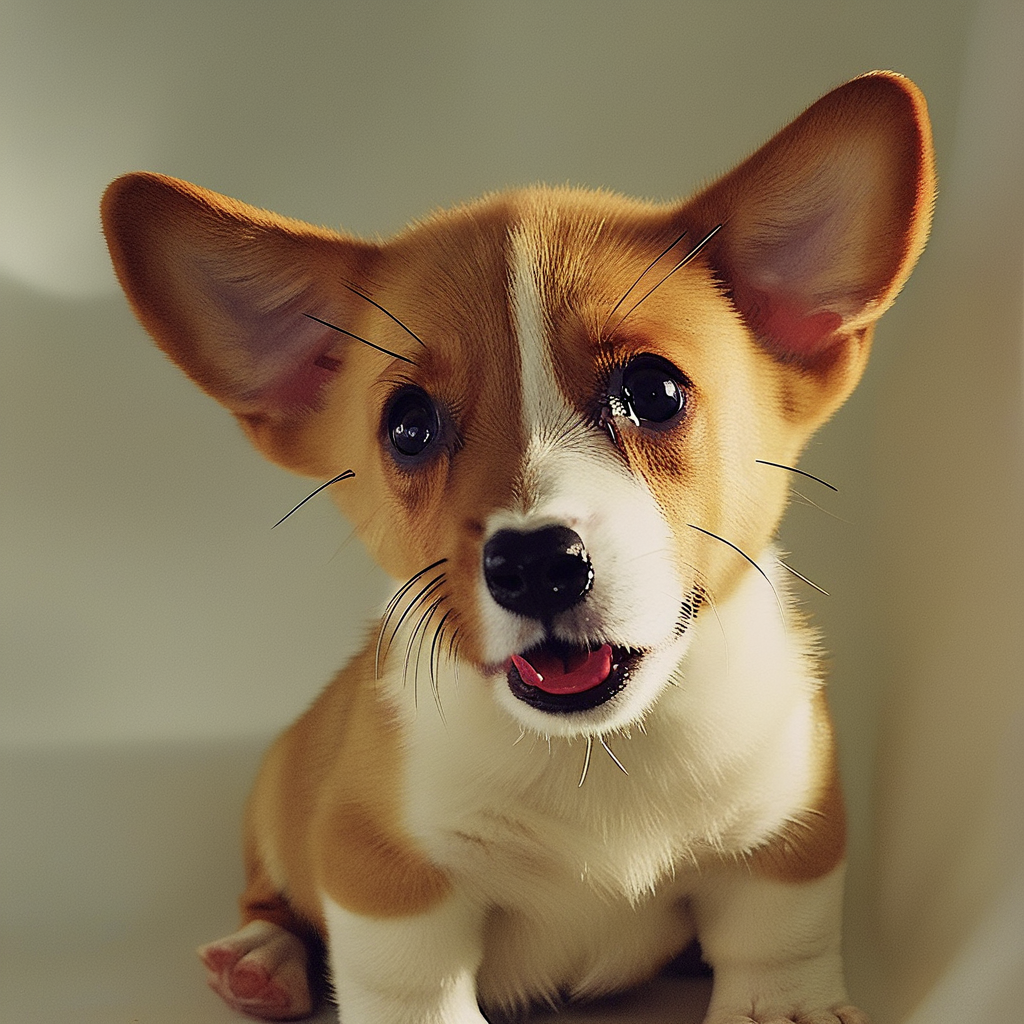

In [3]:
print(path_1)
Image.open(path_1)

base_dynamic/checkpoint-400/sample/clean_sample/base_0.png


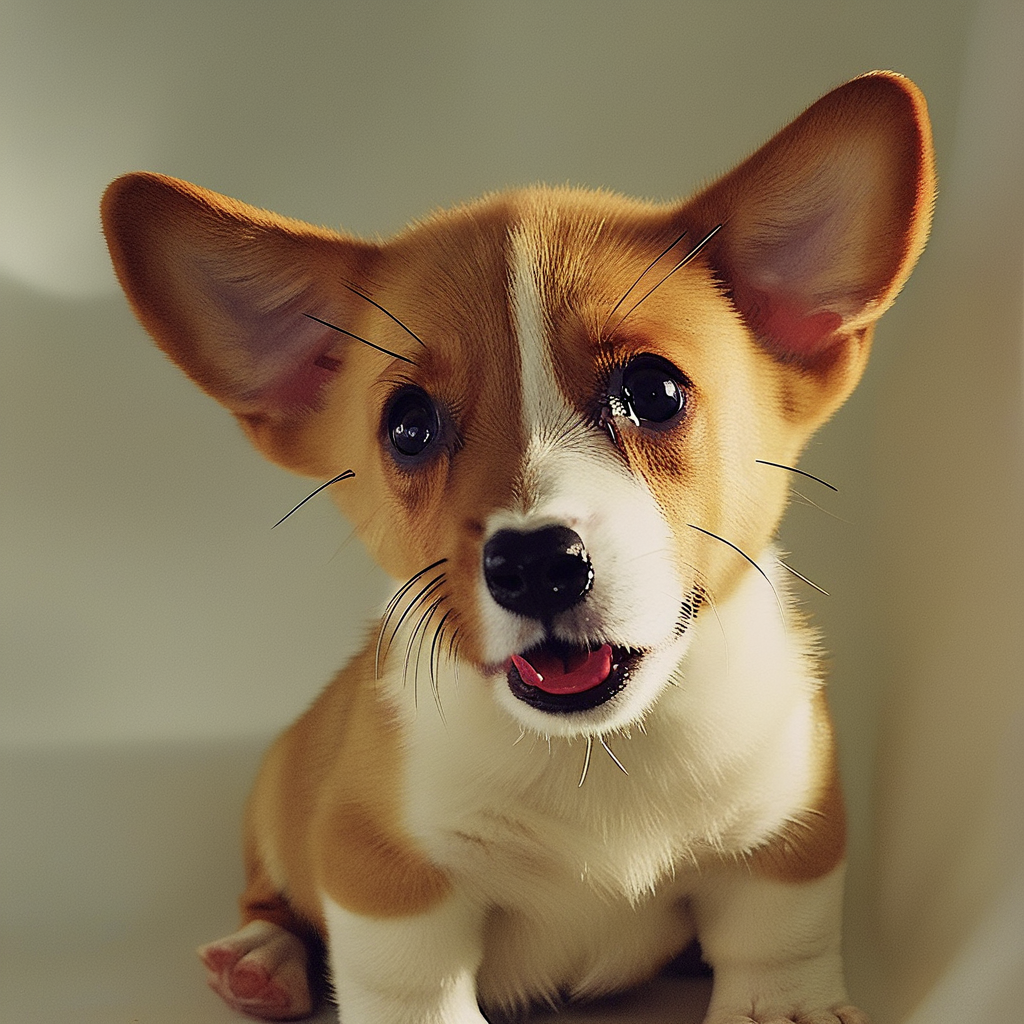

In [4]:
print(path_2)
Image.open(path_2).convert("RGB") # надо обязательно выключать эту опцию

base_dynamic/checkpoint-400/sample/base_0.png


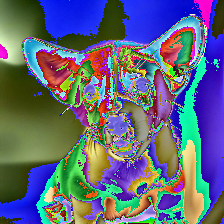

In [21]:
to_pil = ToPILImage()

processed = []
print(path_1)
img = Image.open(path_1)
to_pil(preprocess(img))

base_dynamic/checkpoint-400/sample/clean_sample/base_0.png


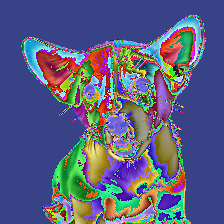

In [22]:
to_pil = ToPILImage()

processed = []
print(path_2)
img = Image.open(path_2)
to_pil(preprocess(img))

In [28]:
processed = []
img = Image.open(path_1).convert("RGB")
processed.append(preprocess(img))

image_input = torch.stack(processed).to(device)
with torch.no_grad():
    image_features_1 = model.encode_image(image_input)

image_features_1 /= image_features_1.norm(dim=-1, keepdim=True)

In [29]:
processed = []
img = Image.open(path_2).convert("RGB")
processed.append(preprocess(img))

image_input = torch.stack(processed).to(device)
with torch.no_grad():
    image_features_2 = model.encode_image(image_input)

image_features_2 /= image_features_2.norm(dim=-1, keepdim=True)

In [30]:
torch.all(image_features_1 == image_features_2)

tensor(True, device='cuda:0')

___